## SETUP & MONTHLY AGGREGATION

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset engineered by Member 1
df = pd.read_csv('swiggy_data_final.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Extract YearMonth for macro-level grouping
df['YearMonth'] = df['Timestamp'].dt.to_period('M').astype(str)

# 3. Aggregate to Monthly Volume
monthly = df.groupby(['YearMonth', 'Product_Name']).agg(
    total_quantity=('Quantity', 'sum')
).reset_index()

print("Data successfully aggregated to monthly volume.")

Data successfully aggregated to monthly volume.


## LAG FEATURES & TRAIN-TEST SPLIT

In [2]:
# 1. Sort chronologically and create the Lag Feature
monthly = monthly.sort_values(['Product_Name', 'YearMonth']).reset_index(drop=True)
monthly['lag_1_month'] = monthly.groupby('Product_Name')['total_quantity'].shift(1)

# Drop the first month which has no historical lag data
monthly = monthly.dropna().reset_index(drop=True)

# 2. Chronological Train-Test Split (Hold out December 2024 for testing)
latest_month = '2024-12'
train_data = monthly[monthly['YearMonth'] < latest_month].copy()
test_data = monthly[monthly['YearMonth'] == latest_month].copy()

# 3. Define Features (X) and Target (y)
features_to_drop = ['YearMonth', 'total_quantity']

X_train = train_data.drop(columns=features_to_drop)
y_train = train_data['total_quantity']
X_test = test_data.drop(columns=features_to_drop)
y_test = test_data['total_quantity']

# Convert categorical column so XGBoost can read it natively
X_train['Product_Name'] = X_train['Product_Name'].astype('category')
X_test['Product_Name'] = X_test['Product_Name'].astype('category')

print(f"Training on {len(X_train)} historical records.")
print(f"Testing on {len(X_test)} predictions for {latest_month}.")

Training on 140 historical records.
Testing on 14 predictions for 2024-12.


## XGBOOST MODEL & DECEMBER FORECAST

In [3]:
print("Training XGBoost Regressor... \n")

# 1. Initialize and Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    enable_categorical=True, random_state=42
)
xgb_model.fit(X_train, y_train)

# 2. Predict the Test Set (December)
xgb_preds = np.clip(xgb_model.predict(X_test), 0, None)

# 3. Output the Final Forecast
results_df = test_data.copy()
results_df['predicted_quantity'] = xgb_preds.round()

final_ranking = results_df[['Product_Name', 'predicted_quantity']].sort_values(
    by='predicted_quantity', ascending=False
).reset_index(drop=True)

print("DECEMBER 2024 INVENTORY FORECAST")
print("-" * 40)
display(final_ranking.head(5))

winner = final_ranking.iloc[0]['Product_Name']
expected_volume = int(final_ranking.iloc[0]['predicted_quantity'])
print(f"\nBUSINESS RECOMMENDATION:")
print(f"Swiggy should prioritize stocking {winner} with an expected volume of {expected_volume} units.")

Training XGBoost Regressor... 

DECEMBER 2024 INVENTORY FORECAST
----------------------------------------


,Product_Name,predicted_quantity
0,Chicken Biryani,366.0
1,Masala Dosa,353.0
2,Idli,251.0
3,Veg Burger,219.0
4,Pepperoni Pizza,214.0



BUSINESS RECOMMENDATION:
Swiggy should prioritize stocking Chicken Biryani with an expected volume of 366 units.


## MODEL SHOWDOWN & EVALUATION

Preparing Scikit-Learn models for Showdown... 


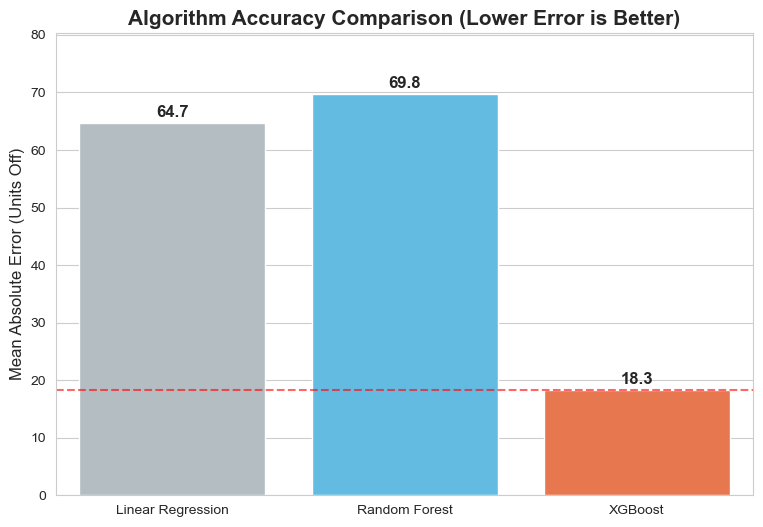

CONCLUSION: XGBoost successfully outperformed both baseline models by adapting to the highly non-linear October sales spike.


In [4]:
print("Preparing Scikit-Learn models for Showdown... ")

# --- DATA PREP FOR LR & RF ---
# Scikit-Learn requires One-Hot Encoding for text categories
X_train_encoded = pd.get_dummies(X_train, columns=['Product_Name'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Product_Name'], drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# --- 1. LINEAR REGRESSION ---
lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)
lr_preds = np.clip(lr_model.predict(X_test_encoded), 0, None)
lr_mae = mean_absolute_error(y_test, lr_preds)

# --- 2. RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train)
rf_preds = np.clip(rf_model.predict(X_test_encoded), 0, None)
rf_mae = mean_absolute_error(y_test, rf_preds)

# --- 3. XGBOOST (From Cell 3) ---
xgb_mae = mean_absolute_error(y_test, xgb_preds)

# --- VISUALIZE THE RESULTS ---
models = ['Linear Regression', 'Random Forest', 'XGBoost']
errors = [lr_mae, rf_mae, xgb_mae]

plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Create bar chart with modern seaborn formatting to avoid warnings
bars = sns.barplot(x=models, y=errors, hue=models, palette=['#B0BEC5', '#4FC3F7', '#FF6B35'], legend=False)

# Add error numbers on top of bars
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Algorithm Accuracy Comparison (Lower Error is Better)', fontsize=15, fontweight='bold')
plt.ylabel('Mean Absolute Error (Units Off)', fontsize=12)
plt.ylim(0, max(errors) * 1.15) 

# Highlight XGBoost
plt.axhline(xgb_mae, color='red', linestyle='--', alpha=0.6)
plt.show()

print("CONCLUSION: XGBoost successfully outperformed both baseline models by adapting to the highly non-linear October sales spike.")

In [5]:
import joblib

# Save the trained XGBoost model to a file
joblib.dump(xgb_model, 'swiggy_xgboost_model.joblib')
print("Model saved successfully!")

Model saved successfully!
